In [23]:
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import seaborn as sns
import pandas as pd
import sys
sys.path.append("../../tools")
import data

master_path = data.PROJECT_ROOT / "data" / "master_workbook.xlsx"

In [ ]:
# ── ETF Universe ─────────────────────────────────────────────────────────────
# Hardcoded metadata from provider fact sheets — last updated 2026-04-09
# Sources: iShares.com, Vanguard.com, SPDR ETFs — refresh quarterly
ETF_META = {
    "VTIP": {"name": "Vanguard Short-Term TIPS",             "issuer": "Vanguard","maturity": "1-3 Month",  "mod_duration": 0.10, "convexity": 0.00, "expense_ratio": 0.1356},
    "SHY":  {"name": "iShares 1-3 Year Treasury Bond",       "issuer": "iShares", "maturity": "1-3 Year",   "mod_duration": 1.83, "convexity": 0.05, "expense_ratio": 0.15},
    "IEI":  {"name": "iShares 3-7 Year Treasury Bond",       "issuer": "iShares", "maturity": "3-7 Year",   "mod_duration": 4.38, "convexity": 0.24, "expense_ratio": 0.15},
    "IEF":  {"name": "iShares 7-10 Year Treasury Bond",      "issuer": "iShares", "maturity": "7-10 Year",  "mod_duration": 7.48, "convexity": 0.69, "expense_ratio": 0.15},
    "TLH":  {"name": "iShares 10-20 Year Treasury Bond",     "issuer": "iShares", "maturity": "10-20 Year", "mod_duration": 11.73,"convexity": 1.65, "expense_ratio": 0.15},
    "TLT":  {"name": "iShares 20+ Year Treasury Bond",       "issuer": "iShares", "maturity": "20+ Year",   "mod_duration": 15.97,"convexity": 3.40, "expense_ratio": 0.15},
    "VGIT": {"name": "Vanguard Intermediate-Term Treasury",  "issuer": "Vanguard","maturity": "3-10 Year",  "mod_duration": 5.30, "convexity": 0.38, "expense_ratio": 0.04},
    "VGLT": {"name": "Vanguard Long-Term Treasury",          "issuer": "Vanguard","maturity": "10-25 Year", "mod_duration": 13.72,"convexity": 2.44, "expense_ratio": 0.04},
    "TIP":  {"name": "iShares TIPS Bond (inflation-linked)", "issuer": "iShares", "maturity": "All",        "mod_duration": 6.84, "convexity": 0.61, "expense_ratio": 0.19},
    "AGG":  {"name": "iShares Core U.S. Aggregate Bond",     "issuer": "iShares", "maturity": "All (Agg)",  "mod_duration": 6.04, "convexity": 0.54, "expense_ratio": 0.03},
}

TICKERS     = list(ETF_META.keys())
PURE_TRSYS  = [t for t in TICKERS if t not in ("TIP", "AGG")]  # pure nominal Treasury ETFs
BENCH       = "AGG"

print("ETF universe loaded:", TICKERS)

ETF universe loaded: ['VTIP', 'SHY', 'IEI', 'IEF', 'TLH', 'TLT', 'VGIT', 'VGLT', 'TIP', 'AGG']


In [25]:
# Pull 5 years of price history for all ETFs
raw = {}
for tk in TICKERS:
    hist = yf.Ticker(tk).history(period="5y")
    hist.index = hist.index.tz_localize(None)
    raw[tk] = hist
    print(f"{tk}: {len(hist)} rows  last={hist.index[-1].date()}  close={hist['Close'].iloc[-1]:.2f}")

# Also pull FRED data from master workbook
df_master = pd.read_excel(master_path, sheet_name="All Data", index_col="date", skiprows=1)

prices = pd.DataFrame({tk: raw[tk]["Close"] for tk in TICKERS}).dropna(how="all")
print("\nPrice matrix shape:", prices.shape)

VTIP: 1256 rows  last=2026-04-10  close=50.05
SHY: 1256 rows  last=2026-04-10  close=82.41
IEI: 1256 rows  last=2026-04-10  close=118.42
IEF: 1256 rows  last=2026-04-10  close=95.27
TLH: 1256 rows  last=2026-04-10  close=100.58
TLT: 1256 rows  last=2026-04-10  close=86.49
VGIT: 1256 rows  last=2026-04-10  close=59.43
VGLT: 1256 rows  last=2026-04-10  close=55.26
TIP: 1256 rows  last=2026-04-10  close=111.02
AGG: 1256 rows  last=2026-04-10  close=99.32

Price matrix shape: (1256, 10)


# Treasury ETF Analysis Workbook

This notebook approaches fixed income positioning from the **ETF lens** rather than individual bond construction.  
The benchmark is the **iShares Core U.S. Aggregate Bond ETF (AGG)** as a proxy for the Bloomberg U.S. Aggregate Bond Index  
(actual Agg holdings are proprietary; AGG is the closest liquid proxy).

Central question throughout: **where on the curve do we want to be, and why does that differ from AGG?**  
What risks are we willing to accept — and which risks are we actually being paid to hold?

## What Is Our Argument?

*(Fill in before each presentation.)*

State the positioning call: are we overweighting, underweighting, or matching AGG duration (~6 years)?  
If we're deviating, which part of the curve — short (VTIP/SHY), belly (IEI/IEF/VGIT), or long (TLH/TLT/VGLT) — and why?  
Does TIPS exposure (TIP) make sense given current real yield and breakeven levels?

**Macro framing:** Where is the Fed in its cycle? What does the yield curve's shape tell us about the market's rate expectations?  
Is the long end being driven by term premium re-pricing, deficit concerns, or foreign flows?

---

### Qualitative / Forward-Looking Thoughts

*Space for current thinking — update each cycle:*

- **Fed path:** What's priced in vs. what we think happens?
- **Kevin Warsh / Fed leadership:** If Warsh gets in, the presumption is tighter, more rules-based policy. What does that mean for the short end vs. long end?
- **Fiscal / supply pressure:** Treasury issuance is elevated. The long end has been absorbing duration the market may not want. Does this persist?
- **Geopolitics / tariff regime:** Tariff uncertainty raises inflation tail risk but also growth downside. Stagflationary mix — complicated for duration.
- **Dollar and foreign demand:** Foreign central banks reducing UST holdings? Impacts long-end term premium.

---

### Current Positioning vs. AGG

| ETF | Position | Duration vs AGG | Rationale |
|-----|----------|----------------|-----------|
| *(fill in)* | | | |

## Benchmark Overview (AGG)

AGG is not a pure Treasury ETF — this distinction matters for understanding what risks we inherit from the benchmark  
and which risks we're *choosing* to take by substituting pure-Treasury ETFs.

**AGG approximate composition:**
- US Treasuries: ~43%
- Mortgage-Backed Securities (MBS): ~26%  ← prepayment risk, convexity drag
- IG Corporates: ~25%  ← credit/spread risk
- Agency & Other: ~6%

Key implication: **AGG is not a pure duration bet.** It embeds credit risk (IG), prepayment/negative convexity (MBS), and agency risk.  
Substituting with pure Treasury ETFs strips out credit and prepayment — we get cleaner duration exposure but give up any spread pickup.

=== AGG Benchmark Summary ===
Latest Close:          $99.32
YTD Return:            +0.45%
1-Year Return:         +5.50%
3-Year Return:         +10.34%
Mod Duration:          6.04 yrs
DV01 (per $100 NAV):   $0.0600
Ann. Volatility (1Y):  4.11%
Expense Ratio:         0.0300%


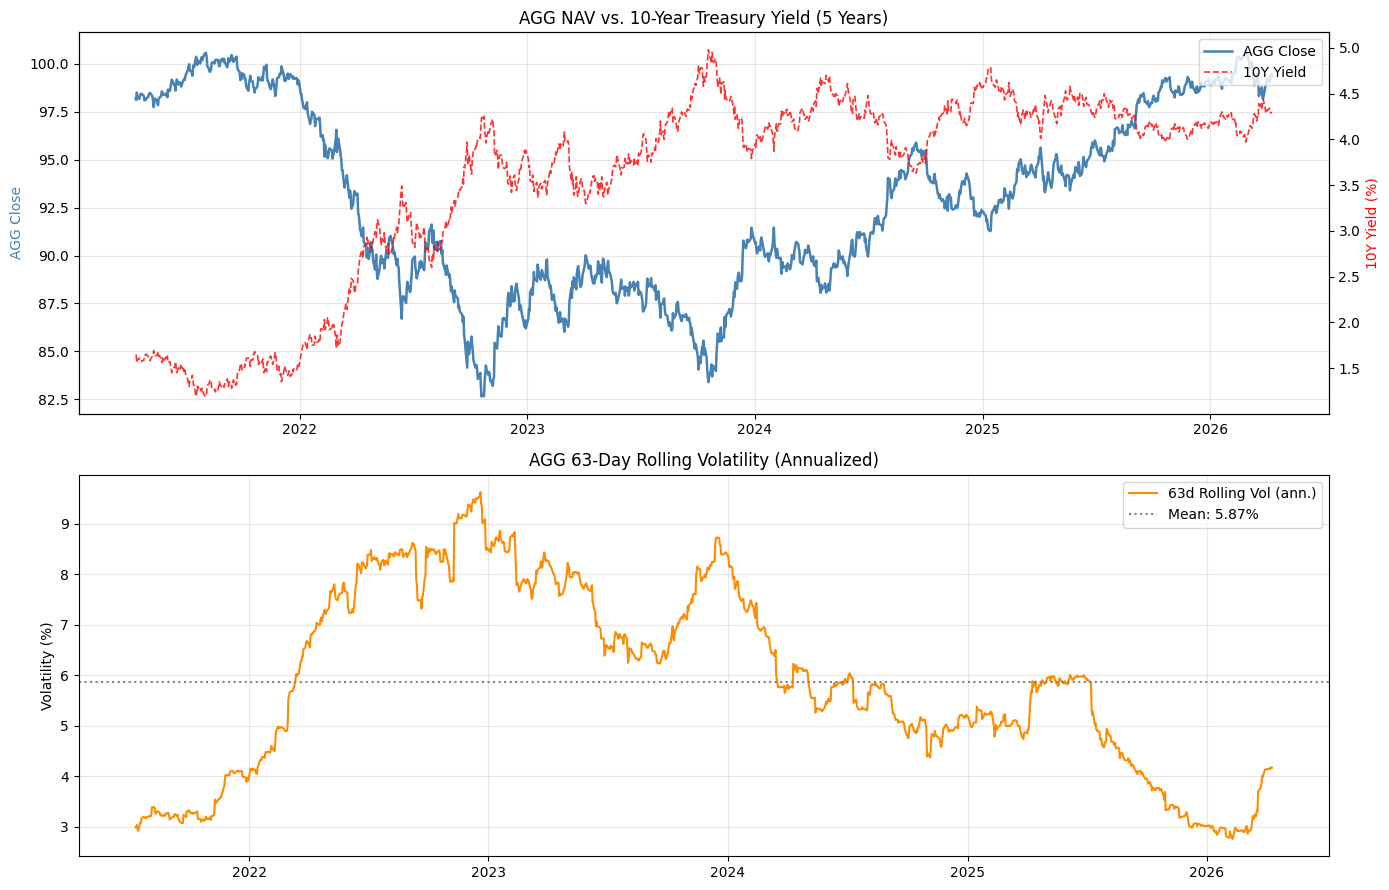

In [26]:
agg = raw["AGG"]
agg_returns = agg["Close"].pct_change().dropna()

# Summary stats
ytd_start = agg[agg.index >= f"{agg.index[-1].year}-01-01"]["Close"].iloc[0]
ytd_ret   = (agg["Close"].iloc[-1] / ytd_start - 1) * 100
ret_1y    = (agg["Close"].iloc[-1] / agg["Close"].iloc[-252] - 1) * 100
ret_3y    = (agg["Close"].iloc[-1] / agg["Close"].iloc[-756] - 1) * 100 if len(agg) > 756 else np.nan
vol_ann   = agg_returns.rolling(252).std().iloc[-1] * np.sqrt(252) * 100
agg_dur   = ETF_META["AGG"]["mod_duration"]
dv01      = agg_dur * agg["Close"].iloc[-1] / 100 * 0.01

print("=== AGG Benchmark Summary ===")
print(f"Latest Close:          ${agg['Close'].iloc[-1]:.2f}")
print(f"YTD Return:            {ytd_ret:+.2f}%")
print(f"1-Year Return:         {ret_1y:+.2f}%")
print(f"3-Year Return:         {ret_3y:+.2f}%" if not np.isnan(ret_3y) else "3-Year:    N/A")
print(f"Mod Duration:          {agg_dur:.2f} yrs")
print(f"DV01 (per $100 NAV):   ${dv01:.4f}")
print(f"Ann. Volatility (1Y):  {vol_ann:.2f}%")
print(f"Expense Ratio:         {ETF_META['AGG']['expense_ratio']:.4f}%")

# AGG price + 10Y yield overlay
t10 = df_master["DGS10"].dropna()
common = agg.index.intersection(t10.index)

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

axes[0].plot(agg.index[1:1260], agg["Close"].iloc[1:1260], color="steelblue", linewidth=1.8, label="AGG Close")
ax0b = axes[0].twinx()
ax0b.plot(common[1:1260], t10[common][1:1260], color="red", linewidth=1.2, linestyle="--", alpha=0.8, label="10Y Yield")
axes[0].set_title("AGG NAV vs. 10-Year Treasury Yield (5 Years)")
axes[0].set_ylabel("AGG Close", color="steelblue")
ax0b.set_ylabel("10Y Yield (%)", color="red")
lines = axes[0].get_lines() + ax0b.get_lines()
axes[0].legend(lines, [l.get_label() for l in lines], loc="upper right")
axes[0].grid(True, alpha=0.3)

roll_vol = agg_returns.rolling(63).std() * np.sqrt(252) * 100
axes[1].plot(agg_returns.index[1:1260], roll_vol.iloc[1:1260], color="darkorange", linewidth=1.5, label="63d Rolling Vol (ann.)")
axes[1].set_title("AGG 63-Day Rolling Volatility (Annualized)")
axes[1].set_ylabel("Volatility (%)")
axes[1].axhline(roll_vol.mean(), color="gray", linestyle=":", label=f"Mean: {roll_vol.mean():.2f}%")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## ETF Comparison vs. Benchmark

A key difference from individual bond analysis: **ETF duration is sticky**.  
As bonds roll off the ETF manager's balance sheet, they're replaced with new issues at current market yields.  
This means we don't get the "pull to par" of individual bonds — but we also don't get locked into a duration profile that drifts away from our target.

Mark-to-market matters here: NAV moves daily with rates. A 16-year duration (TLT) will lose ~16% in price for every 100bps parallel shift up.

**ETF-specific considerations:**
- **Expense ratio drag** compounds over time — Vanguard ETFs (VGIT, VGLT at 0.04%) vs iShares (0.15%) is a meaningful difference
- **Liquidity:** All listed ETFs are highly liquid; bid-ask spreads are tight
- **Tax treatment:** Treasury ETF dividends are exempt from state/local income tax; AGG (with corporates/MBS) is not
- **Tracking error:** Generally very low for these large ETFs; negligible for positioning decisions

       Maturity Range  Mod Duration  Convexity  Exp Ratio %   Close  Div Yield %  1Y Return %  1Y Vol %  Avg Daily $Vol (B)  Dur vs AGG
Ticker                                                                                                                                 
VTIP        1-3 Month          0.10       0.00       0.1356   50.05         3.61         4.31      1.75               0.141       -5.94
SHY          1-3 Year          1.83       0.05       0.1500   82.41         3.72         3.55      1.40               0.450       -4.21
IEI          3-7 Year          4.38       0.24       0.1500  118.42         3.57         4.26      3.26               0.279       -1.66
IEF         7-10 Year          7.48       0.69       0.1500   95.27         3.84         4.59      5.09               1.068        1.44
TLH        10-20 Year         11.73       1.65       0.1500  100.58         4.36         3.52      8.67               0.154        5.69
TLT          20+ Year         15.97       3.40  

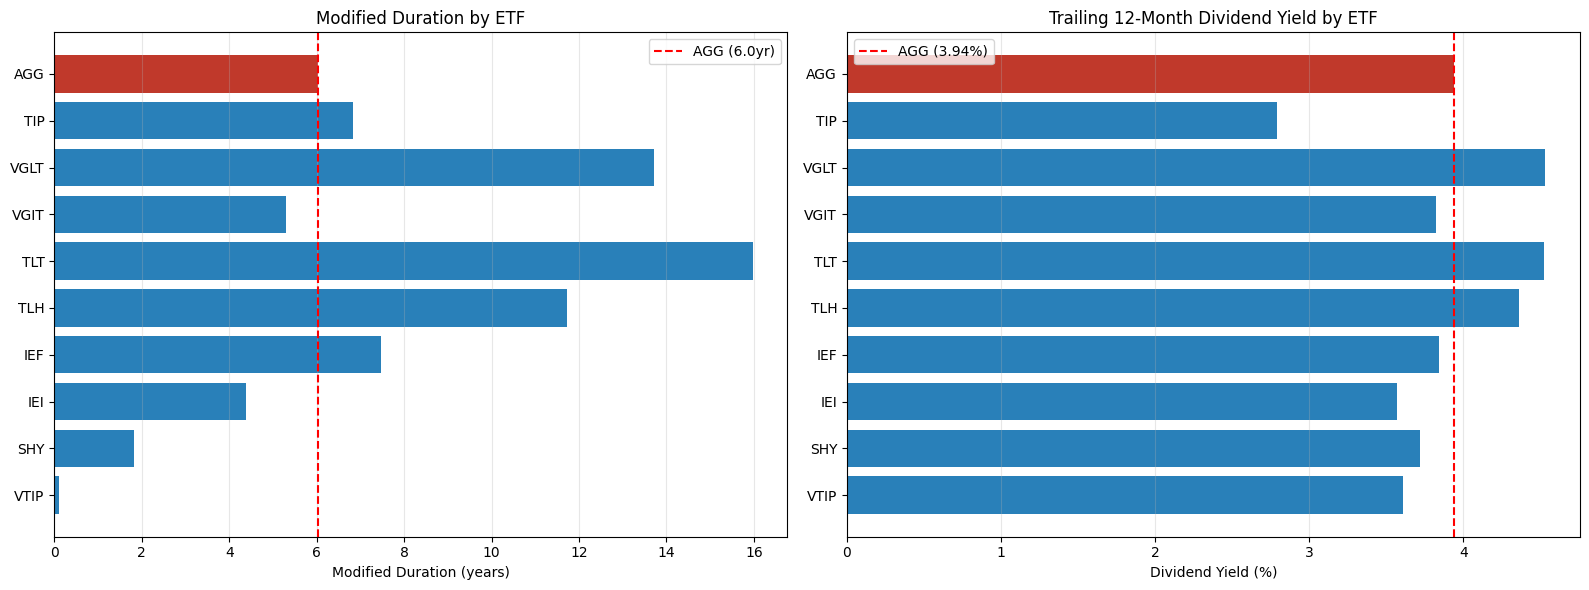

In [27]:
# Build comparison table
rows = []
for tk in TICKERS:
    hist   = raw[tk]
    meta   = ETF_META[tk]
    close  = hist["Close"].iloc[-1]
    ret_1y = (close / hist["Close"].iloc[-252] - 1) * 100 if len(hist) > 252 else np.nan
    vol_1y = hist["Close"].pct_change().rolling(252).std().iloc[-1] * np.sqrt(252) * 100
    div_ttm = hist["Dividends"].tail(252).sum()
    div_yield = div_ttm / close * 100
    aum_proxy = hist["Volume"].tail(63).mean() * close / 1e9  # rough $ volume proxy
    rows.append({
        "Ticker": tk,
        "Maturity Range": meta["maturity"],
        "Mod Duration": meta["mod_duration"],
        "Convexity":    meta["convexity"],
        "Exp Ratio %":  meta["expense_ratio"],
        "Close": round(close, 2),
        "Div Yield %":  round(div_yield, 2),
        "1Y Return %":  round(ret_1y, 2),
        "1Y Vol %":     round(vol_1y, 2),
        "Avg Daily $Vol (B)": round(aum_proxy, 3),
    })

df_compare = pd.DataFrame(rows).set_index("Ticker")
bench_row  = df_compare.loc[BENCH]
df_compare["Dur vs AGG"] = (df_compare["Mod Duration"] - bench_row["Mod Duration"]).round(2)
print(df_compare.to_string())

# Duration ladder bar chart
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = ["#c0392b" if tk == BENCH else "#2980b9" for tk in df_compare.index]
axes[0].barh(df_compare.index, df_compare["Mod Duration"], color=colors)
axes[0].axvline(bench_row["Mod Duration"], color="red", linestyle="--", linewidth=1.5, label=f"AGG ({bench_row['Mod Duration']:.1f}yr)")
axes[0].set_title("Modified Duration by ETF")
axes[0].set_xlabel("Modified Duration (years)")
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis="x")

axes[1].barh(df_compare.index, df_compare["Div Yield %"], color=colors)
axes[1].axvline(bench_row["Div Yield %"], color="red", linestyle="--", linewidth=1.5, label=f"AGG ({bench_row['Div Yield %']:.2f}%)")
axes[1].set_title("Trailing 12-Month Dividend Yield by ETF")
axes[1].set_xlabel("Dividend Yield (%)")
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis="x")

plt.tight_layout()
plt.show()

## Opportunities

Which maturities look attractive on a risk-adjusted basis? Where is the curve paying us for duration risk vs. just repricing risk?  
Key metrics: **carry** (yield pickup per unit of duration), **real yield** (compensation after inflation), **term premium** (extra yield for locking up duration).

**ETF-specific opportunity framing:**
- If the curve is steep (short rates < long rates), owning longer-duration ETFs earns more carry — and the ETF roll naturally captures roll-down as duration decays and is reset
- If the curve is flat/inverted, short-duration ETFs (VTIP/SHY) offer similar yield with far less mark-to-market risk
- TIPS (TIP): worth holding when real yields are high and breakeven inflation looks cheap relative to expected CPI

---

### Qualitative / Forward-Looking Thoughts

- *Curve steepener thesis: does the belly (IEI/IEF/VGIT) offer the best carry-to-duration tradeoff right now?*
- *Where is the Fed likely to cut/hold, and what does that mean for the front end?*
- *Is there a fiscal premium building in the long end (30Y+) that makes TLT/VGLT look cheap on term premium?*
- *Geopolitical/tariff-driven inflation: does TIP make sense as a hedge?*

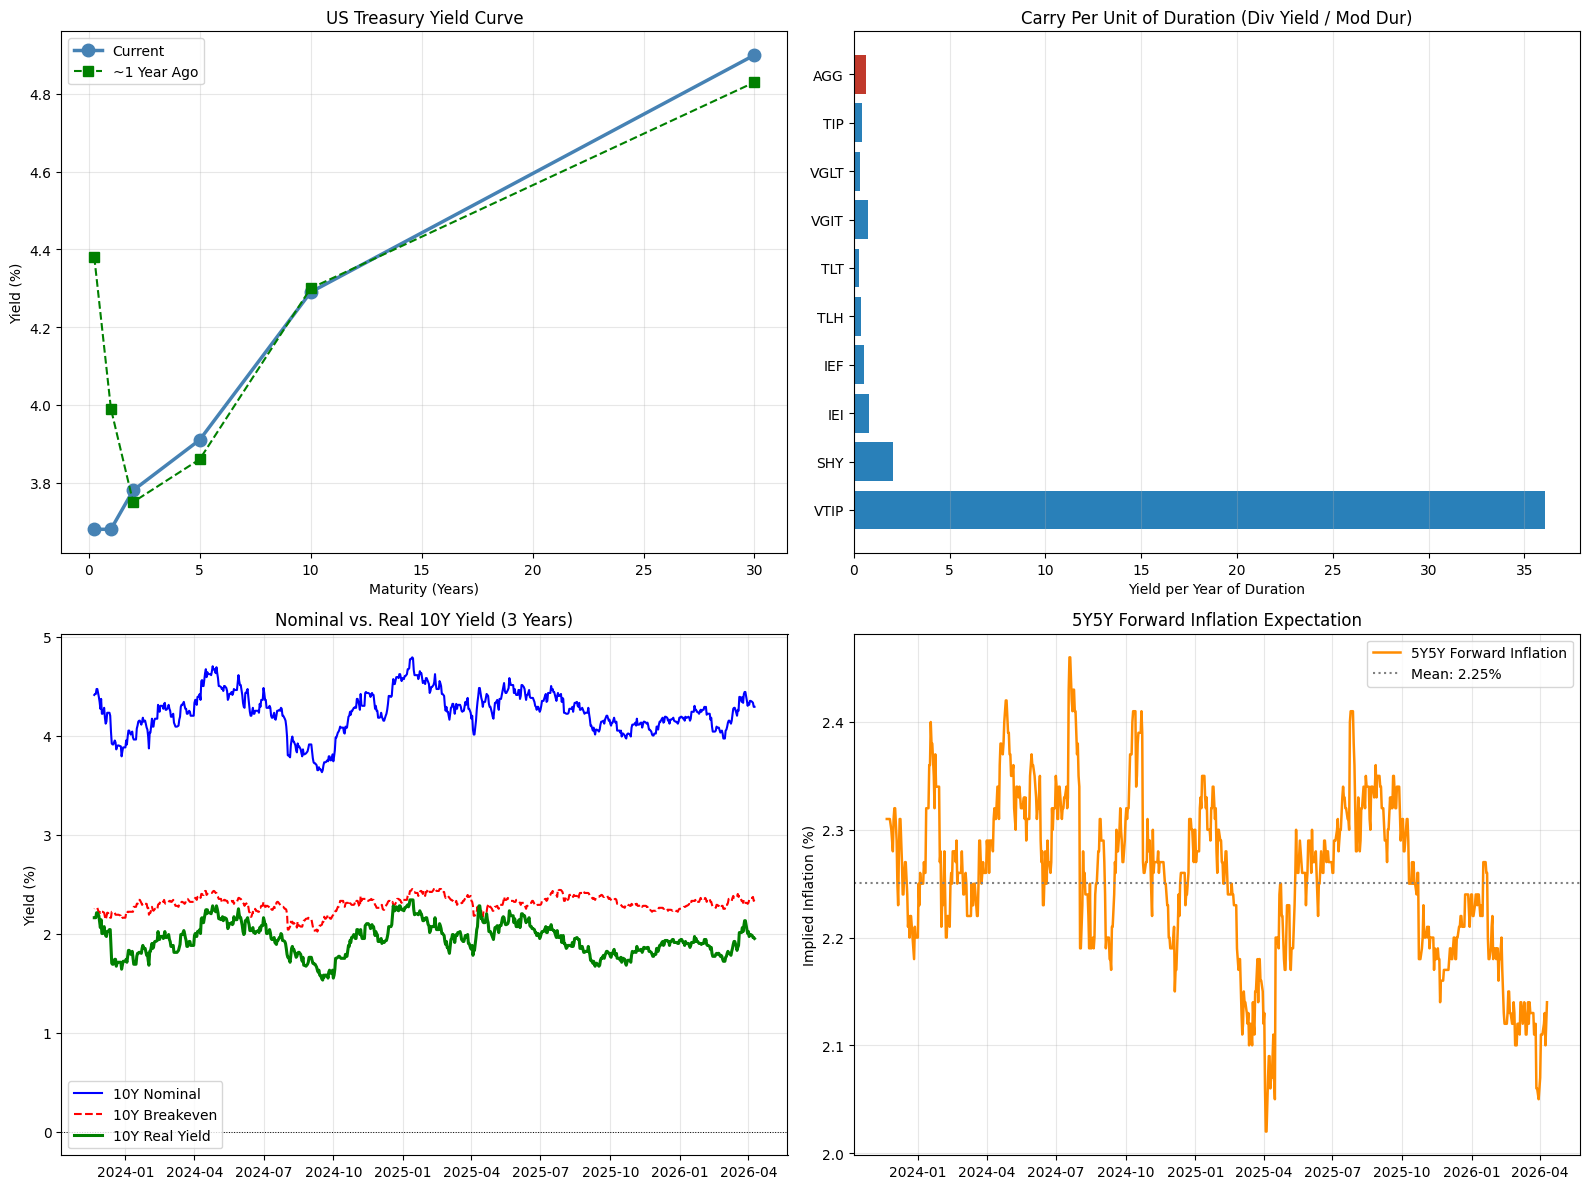


=== Carry per Unit of Duration ===
  VTIP : 36.100  (yield 3.61% / dur 0.10yr)
  SHY  : 2.033  (yield 3.72% / dur 1.83yr)
  IEI  : 0.815  (yield 3.57% / dur 4.38yr)
  VGIT : 0.721  (yield 3.82% / dur 5.30yr)
  AGG  : 0.652  (yield 3.94% / dur 6.04yr)
  IEF  : 0.513  (yield 3.84% / dur 7.48yr)
  TIP  : 0.408  (yield 2.79% / dur 6.84yr)
  TLH  : 0.372  (yield 4.36% / dur 11.73yr)
  VGLT : 0.330  (yield 4.53% / dur 13.72yr)
  TLT  : 0.283  (yield 4.52% / dur 15.97yr)


In [28]:
tenors_fred = ["DGS3MO", "DGS1", "DGS2", "DGS5", "DGS10", "DGS30"]
labels      = ["3M", "1Y", "2Y", "5Y", "10Y", "30Y"]
maturities  = [0.25, 1, 2, 5, 10, 30]

curve_now = [df_master[t].dropna().iloc[0]   for t in tenors_fred]
curve_1y  = [df_master[t].dropna().iloc[252] for t in tenors_fred]

# Carry-to-duration: yield / modified duration — which ETF pays most per year of rate risk
carry_dur = {tk: df_compare.loc[tk, "Div Yield %"] / ETF_META[tk]["mod_duration"]
             if ETF_META[tk]["mod_duration"] > 0 else np.nan
             for tk in TICKERS}

t10_nom = df_master["DGS10"].dropna()
t10_be  = df_master["T10YIE"].dropna()
common_idx = t10_nom.index.intersection(t10_be.index)
real_10y = t10_nom[common_idx] - t10_be[common_idx]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Yield curve
axes[0,0].plot(maturities, curve_now, "o-", color="steelblue", linewidth=2.5, markersize=9, label="Current")
axes[0,0].plot(maturities, curve_1y,  "s--", color="green",    linewidth=1.5, markersize=7, label="~1 Year Ago")
axes[0,0].set_title("US Treasury Yield Curve")
axes[0,0].set_xlabel("Maturity (Years)")
axes[0,0].set_ylabel("Yield (%)")
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Carry per unit of duration
cd_vals = [carry_dur[tk] for tk in TICKERS if tk not in ()]
axes[0,1].barh([tk for tk in TICKERS if tk not in ()], cd_vals, color=["#c0392b" if tk == BENCH else "#2980b9" for tk in TICKERS])
axes[0,1].set_title("Carry Per Unit of Duration (Div Yield / Mod Dur)")
axes[0,1].set_xlabel("Yield per Year of Duration")
axes[0,1].grid(True, alpha=0.3, axis="x")

# Real 10Y yield history
window = 756
axes[1,0].plot(common_idx[1:window], t10_nom[common_idx][1:window], color="blue",  linewidth=1.5, label="10Y Nominal")
axes[1,0].plot(common_idx[1:window], t10_be[common_idx][1:window],  color="red",   linewidth=1.5, linestyle="--", label="10Y Breakeven")
axes[1,0].plot(common_idx[1:window], real_10y[1:window],             color="green", linewidth=2.2, label="10Y Real Yield")
axes[1,0].axhline(0, color="black", linewidth=0.7, linestyle=":")
axes[1,0].set_title("Nominal vs. Real 10Y Yield (3 Years)")
axes[1,0].set_ylabel("Yield (%)")
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# 5Y5Y forward inflation
fwd_5y5y = df_master["T5YIFR"].dropna()
axes[1,1].plot(fwd_5y5y.index[:window], fwd_5y5y[:window], color="darkorange", linewidth=1.8, label="5Y5Y Forward Inflation")
axes[1,1].axhline(fwd_5y5y.mean(), color="gray", linestyle=":", label=f"Mean: {fwd_5y5y.mean():.2f}%")
axes[1,1].set_title("5Y5Y Forward Inflation Expectation")
axes[1,1].set_ylabel("Implied Inflation (%)")
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n=== Carry per Unit of Duration ===")
for tk, val in sorted(carry_dur.items(), key=lambda x: -x[1] if not np.isnan(x[1]) else 0):
    print(f"  {tk:5s}: {val:.3f}  (yield {df_compare.loc[tk,'Div Yield %']:.2f}% / dur {ETF_META[tk]['mod_duration']:.2f}yr)")

## Risks

**Risks specific to ETF-based fixed income positioning (vs. individual bonds):**

- **Mark-to-market NAV impact:** Unlike holding a bond to maturity, ETF NAV reflects current market prices daily. A 100bps rate rise hits TLT ~16%, IEF ~7.5%, SHY ~1.8%. This directly affects dividends and portfolio value.
- **No pull-to-par:** ETFs never "mature." They continuously roll into new bonds at current yields. There's no guaranteed return of principal — though if rates revert, NAV recovers.
- **Reinvestment risk:** Dividends must be reinvested. In a falling-rate environment this is a tailwind (reinvest at lower yields but higher prices). In a rising-rate environment, you're reinvesting at higher yields but that only helps if you hold long enough.
- **Duration drift (minimal):** ETF managers rebalance to maintain target duration ranges — but within a range. IEF's 7.5yr duration can shift slightly.

---

### Qualitative / Tail Scenarios

- **Fed surprise (hawkish):** Warsh-style tightening or sticky inflation → front end blows out, short-duration ETFs (SHY, VTIP) protect
- **Fiscal shock:** US debt ceiling crisis or rating downgrade → long end sells off sharply; TLT/VGLT take the hit
- **Foreign selling:** Japan, China reducing UST holdings → term premium reprices higher, long end cheapens
- **Stagflation:** Rising inflation + slowing growth → real yields stay elevated, TIPS (TIP) outperforms nominals
- **Risk-off / recession:** Classic flight-to-quality → long Treasuries rally sharply; TLT is the beneficiary

=== ETF Price Impact of Parallel Rate Shocks (%) ===
ETF       Dur  Convex  +25bp  +50bp  +100bp  +200bp
---------------------------------------------------
VTIP     0.10    0.00   -2.5%   -5.0%  -10.0%  -20.0%
SHY      1.83    0.05  -45.6%  -90.9%  -180.5%  -356.0%
IEI      4.38    0.24  -108.7%  -216.0%  -426.0%  -828.0%
IEF      7.48    0.69  -184.8%  -365.4%  -713.5%  -1358.0%
TLH     11.73    1.65  -288.1%  -565.9%  -1090.5%  -2016.0%
TLT     15.97    3.40  -388.6%  -756.0%  -1427.0%  -2514.0%
VGIT     5.30    0.38  -131.3%  -260.2%  -511.0%  -984.0%
VGLT    13.72    2.44  -335.4%  -655.5%  -1250.0%  -2256.0%
TIP      6.84    0.61  -169.1%  -334.4%  -653.5%  -1246.0%
AGG      6.04    0.54  -149.3%  -295.2%  -577.0%  -1100.0%


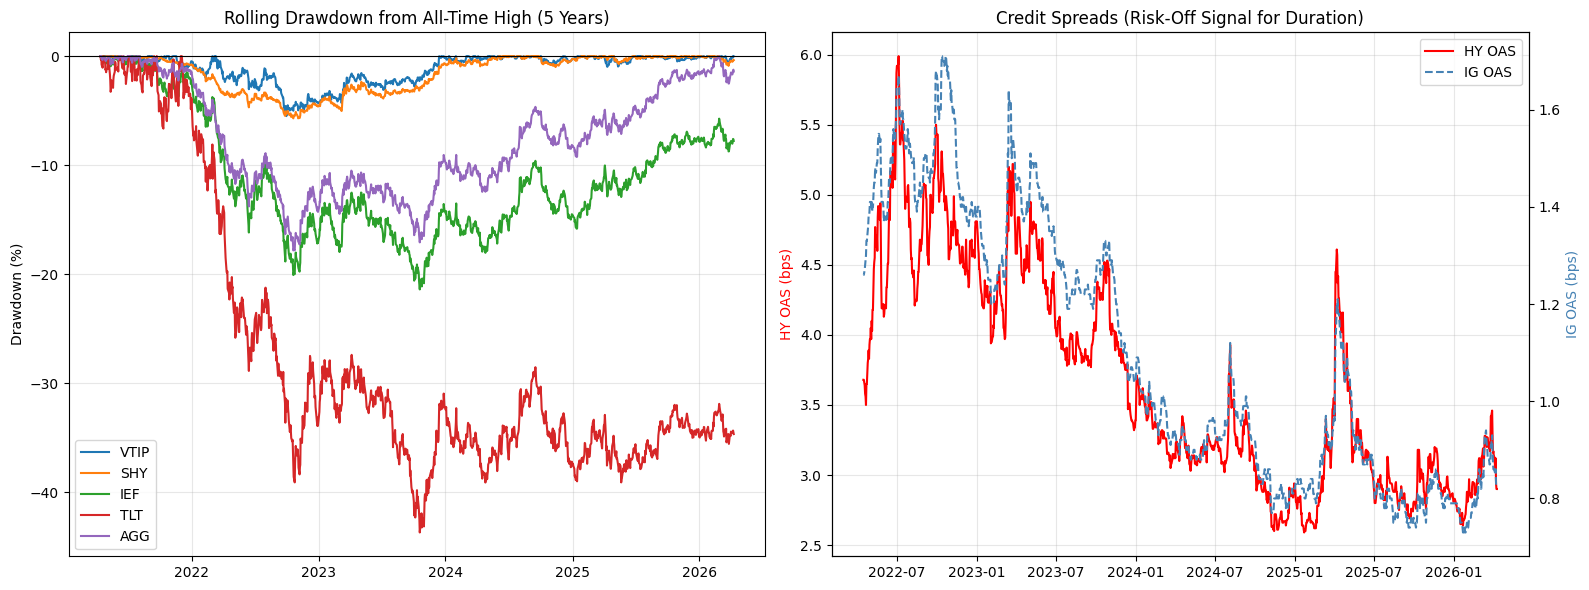

In [29]:
# Duration risk table: price impact of parallel rate shocks
shocks_bps = [25, 50, 100, 200]
print("=== ETF Price Impact of Parallel Rate Shocks (%) ===")
header = f"{'ETF':<6} {'Dur':>6} {'Convex':>7}" + "".join([f"  +{s}bp" for s in shocks_bps])
print(header)
print("-" * len(header))
for tk in TICKERS:
    d = ETF_META[tk]["mod_duration"]
    c = ETF_META[tk]["convexity"]
    # Price change ≈ -D*Δy + 0.5*C*(Δy)^2
    impacts = [(-d*(s/100) + 0.5*c*(s/100)**2)*100 for s in shocks_bps]
    row = f"{tk:<6} {d:>6.2f} {c:>7.2f}" + "".join([f"  {v:>+5.1f}%" for v in impacts])
    print(row)

# Historical drawdowns for long-duration ETFs
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plot_tickers = ["VTIP", "SHY", "IEF", "TLT", "AGG"]
for tk in plot_tickers:
    p = raw[tk]["Close"]
    roll_max = p.cummax()
    drawdown = (p / roll_max - 1) * 100
    axes[0].plot(drawdown.index[-1260:], drawdown.iloc[-1260:], linewidth=1.5, label=tk)
axes[0].set_title("Rolling Drawdown from All-Time High (5 Years)")
axes[0].set_ylabel("Drawdown (%)")
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Spread indicators as risk overlay
hy_oas = df_master["BAMLH0A0HYM2"].dropna()
ig_oas = df_master["BAMLC0A0CM"].dropna()
axes[1].plot(hy_oas.index[:1260], hy_oas.iloc[:1260], color="red",   linewidth=1.5, label="HY OAS")
ax1b = axes[1].twinx()
ax1b.plot(ig_oas.index[:1260], ig_oas.iloc[:1260], color="steelblue", linewidth=1.5, linestyle="--", label="IG OAS")
axes[1].set_title("Credit Spreads (Risk-Off Signal for Duration)")
axes[1].set_ylabel("HY OAS (bps)", color="red")
ax1b.set_ylabel("IG OAS (bps)", color="steelblue")
lines = axes[1].get_lines() + ax1b.get_lines()
axes[1].legend(lines, [l.get_label() for l in lines])
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Curve Expectations

The shape of the curve is the primary input for ETF selection — it determines **where carry is richest** and  
**which duration bucket we're being paid to hold** vs. which we're just taking risk in.

**Key curve shape signals:**
- **Steep (short < long):** Long-duration ETFs (TLT, VGLT) earn more carry; roll-down works in our favor as the belly cheapens
- **Flat/inverted:** Short-duration ETFs capture similar yield with less mark-to-market risk; belly may be the sweet spot
- **Bear steepener (long rates rising while short rates fall):** Worst case for long-duration ETFs; prefer VTIP/SHY
- **Bull steepener (short rates falling fast):** Front end benefits most; intermediate (IEI/IEF) also performs

---

### Qualitative / Curve Thesis

- *12-24 month view on curve shape: steepener, flattener, or unchanged?*
- *What drives it: Fed cuts repricing, fiscal premium in long end, or neutral rate debate?*
- *Butterfly view: is the belly (5Y) rich or cheap relative to wings?*

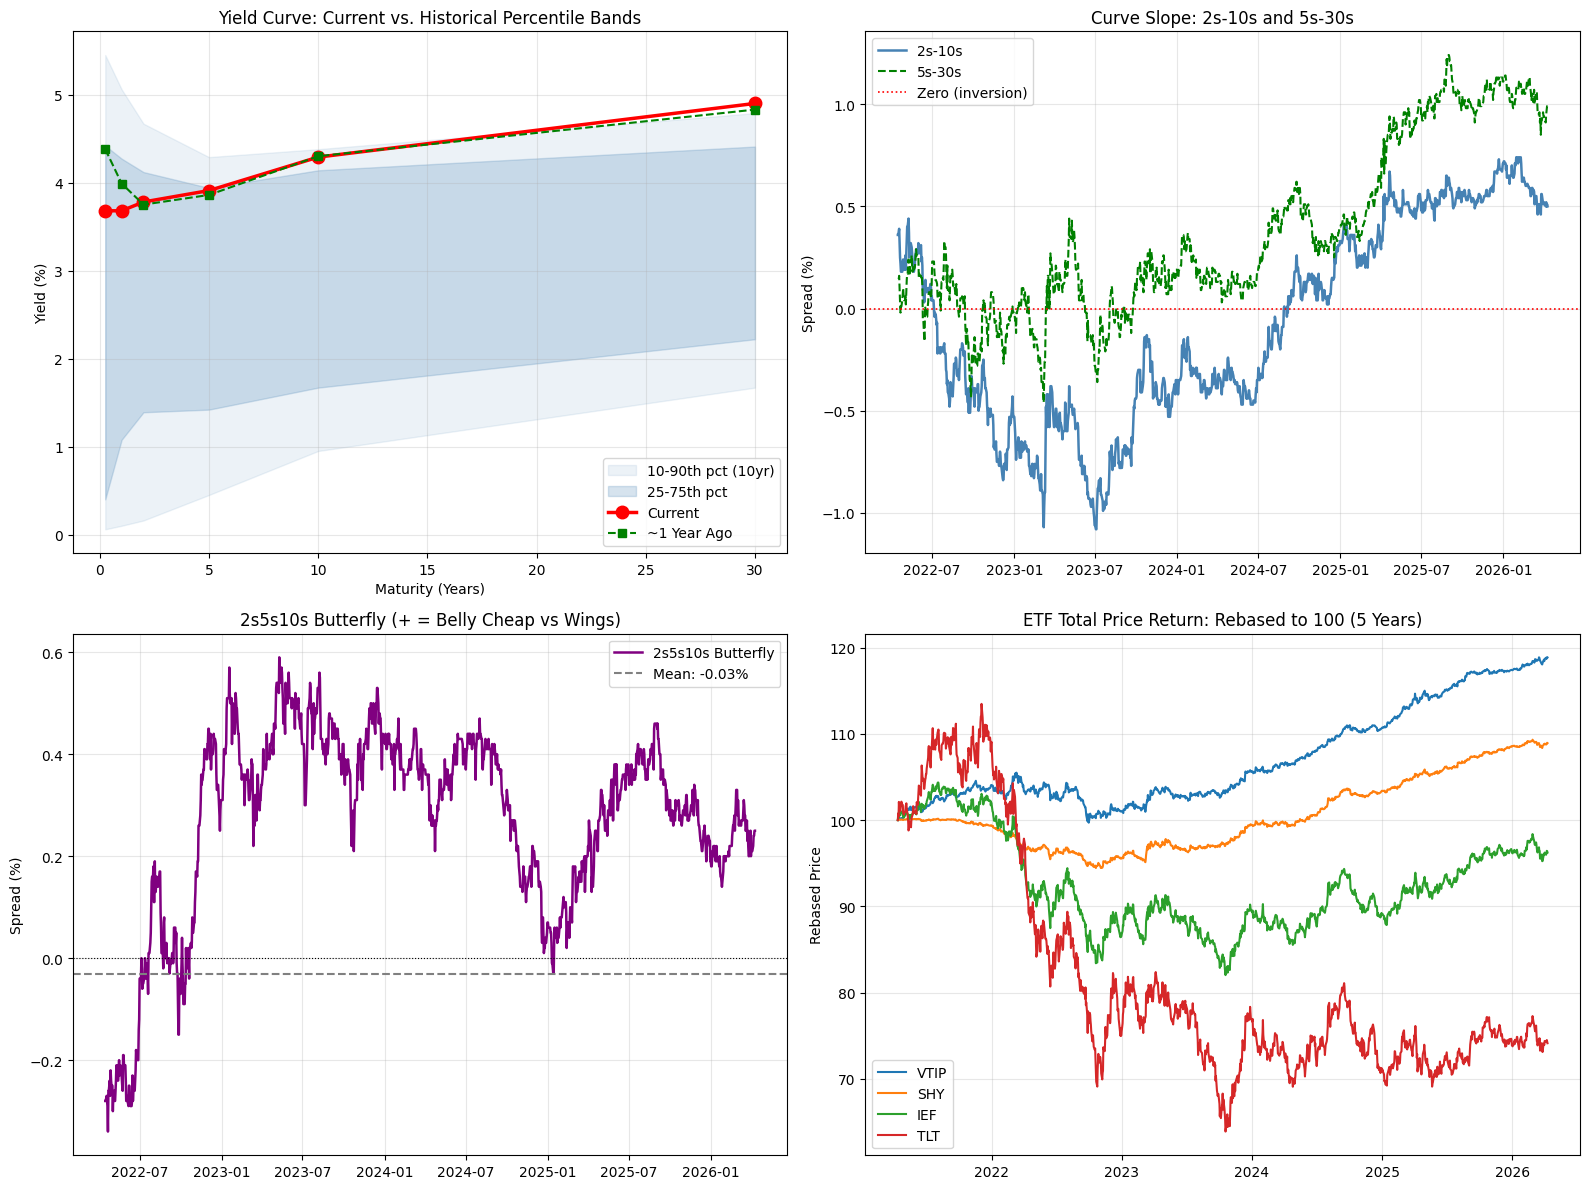


2s-10s current:  +0.50%   mean: +0.85%
5s-30s current:  +0.99%   mean: +0.79%
Butterfly:       +0.25%   mean: -0.03%


In [30]:
slope_2s10s   = df_master["T10Y2Y"].dropna()
slope_5s30s   = (df_master["DGS30"] - df_master["DGS5"]).dropna()
butterfly     = (df_master["DGS2"] + df_master["DGS10"] - 2*df_master["DGS5"]).dropna()

# Historical percentile bands for the current curve
tenors_series = {lbl: df_master[t].dropna() for lbl, t in zip(labels, tenors_fred)}
lookback = min(min(len(s) for s in tenors_series.values()), 2520)
hist_mat = np.array([[tenors_series[lbl].iloc[i] for lbl in labels] for i in range(lookback)])
p10 = np.nanpercentile(hist_mat, 10, axis=0)
p25 = np.nanpercentile(hist_mat, 25, axis=0)
p75 = np.nanpercentile(hist_mat, 75, axis=0)
p90 = np.nanpercentile(hist_mat, 90, axis=0)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Curve with percentile bands
axes[0,0].fill_between(maturities, p10, p90, alpha=0.10, color="steelblue", label=f"10-90th pct ({lookback//252:.0f}yr)")
axes[0,0].fill_between(maturities, p25, p75, alpha=0.22, color="steelblue", label="25-75th pct")
axes[0,0].plot(maturities, curve_now, "o-", color="red",   linewidth=2.5, markersize=9, label="Current")
axes[0,0].plot(maturities, curve_1y,  "s--",color="green", linewidth=1.5, markersize=6, label="~1 Year Ago")
axes[0,0].set_title("Yield Curve: Current vs. Historical Percentile Bands")
axes[0,0].set_xlabel("Maturity (Years)")
axes[0,0].set_ylabel("Yield (%)")
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# 2s-10s slope
axes[0,1].plot(slope_2s10s.index[:1260], slope_2s10s.iloc[:1260], color="steelblue", linewidth=1.8, label="2s-10s")
axes[0,1].plot(slope_5s30s.index[:1260], slope_5s30s.iloc[:1260], color="green",     linewidth=1.5, linestyle="--", label="5s-30s")
axes[0,1].axhline(0, color="red", linewidth=1.2, linestyle=":", label="Zero (inversion)")
axes[0,1].set_title("Curve Slope: 2s-10s and 5s-30s")
axes[0,1].set_ylabel("Spread (%)")
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# Butterfly
axes[1,0].plot(butterfly.index[:1260], butterfly.iloc[:1260], color="purple", linewidth=1.8, label="2s5s10s Butterfly")
axes[1,0].axhline(0, color="black", linewidth=0.8, linestyle=":")
axes[1,0].axhline(butterfly.mean(), color="gray", linestyle="--", label=f"Mean: {butterfly.mean():.2f}%")
axes[1,0].set_title("2s5s10s Butterfly (+ = Belly Cheap vs Wings)")
axes[1,0].set_ylabel("Spread (%)")
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# Rolling performance of ETFs by duration bucket
plot_tks = ["VTIP", "SHY", "IEF", "TLT"]
for tk in plot_tks:
    p = raw[tk]["Close"]
    rebased = (p / p.iloc[0]) * 100
    axes[1,1].plot(rebased.index[-1260:], rebased.iloc[-1260:], linewidth=1.5, label=tk)
axes[1,1].set_title("ETF Total Price Return: Rebased to 100 (5 Years)")
axes[1,1].set_ylabel("Rebased Price")
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n2s-10s current:  {slope_2s10s.iloc[0]:+.2f}%   mean: {slope_2s10s.mean():+.2f}%")
print(f"5s-30s current:  {slope_5s30s.iloc[0]:+.2f}%   mean: {slope_5s30s.mean():+.2f}%")
print(f"Butterfly:       {butterfly.iloc[0]:+.2f}%   mean: {butterfly.mean():+.2f}%")

## Spread Comparison

For pure Treasury ETFs, spread comparison primarily means **duration-adjusted carry vs. AGG** —  
how much yield are we picking up or giving up by deviating from benchmark duration?

The other angle: AGG carries ~25bps of IG credit spread and some implicit MBS prepayment premium.  
By holding pure Treasury ETFs we give up that spread. Is the cleaner duration exposure worth it?  
Or do we want AGG's diversified credit/duration mix?

**Roll-down yield (curve slope benefit):**  
When the curve is upward-sloping, an intermediate ETF earns roll-down yield as its bonds age into shorter maturities  
and get priced at lower yields. The ETF manager then replaces them with longer bonds at higher yields — capturing the spread again.

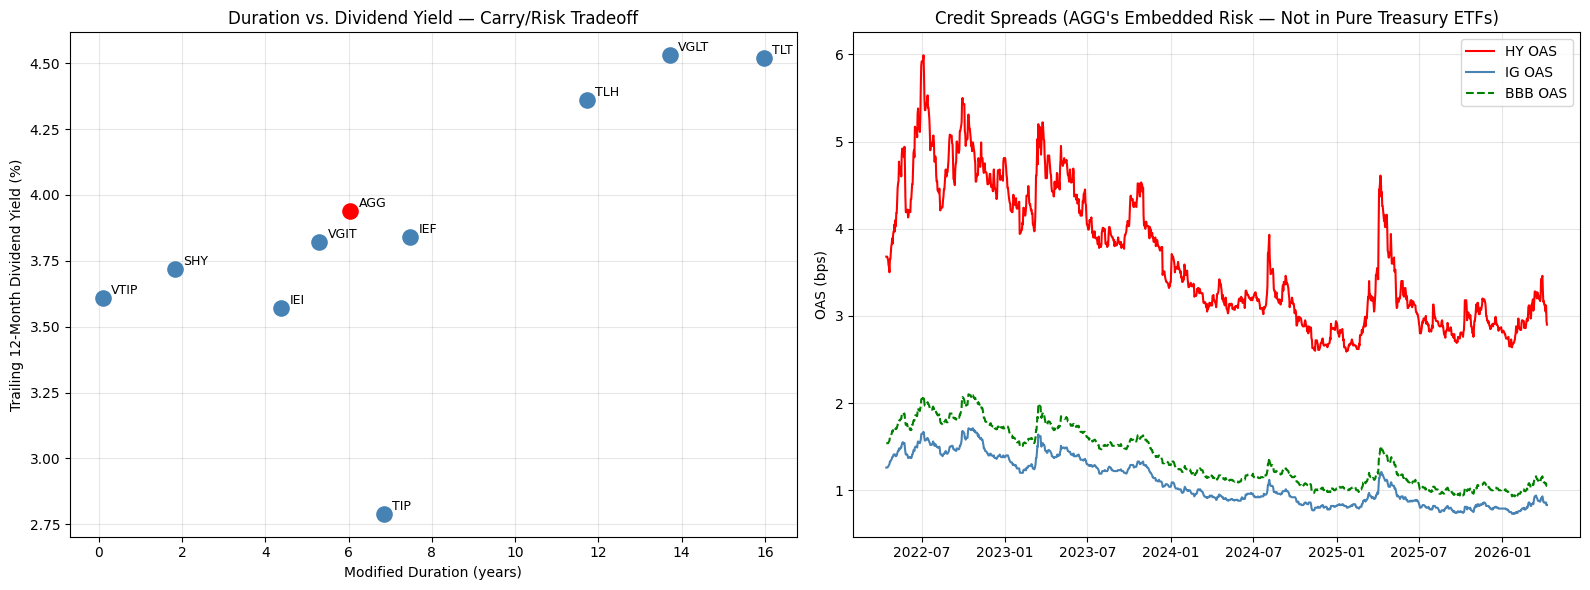


=== Yield vs. AGG Benchmark ===
  VTIP : 3.61%  (-0.33% vs AGG)
  SHY  : 3.72%  (-0.22% vs AGG)
  IEI  : 3.57%  (-0.37% vs AGG)
  IEF  : 3.84%  (-0.10% vs AGG)
  TLH  : 4.36%  (+0.42% vs AGG)
  TLT  : 4.52%  (+0.58% vs AGG)
  VGIT : 3.82%  (-0.12% vs AGG)
  VGLT : 4.53%  (+0.59% vs AGG)
  TIP  : 2.79%  (-1.15% vs AGG)
  AGG  : 3.94%  (+0.00% vs AGG)


In [31]:
# Yield-to-duration efficiency: annualized yield per year of duration for each ETF
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Duration vs. Dividend Yield scatter
for tk in TICKERS:
    d = ETF_META[tk]["mod_duration"]
    y = df_compare.loc[tk, "Div Yield %"]
    color = "red" if tk == BENCH else "steelblue"
    axes[0].scatter(d, y, s=120, color=color, zorder=3)
    axes[0].annotate(tk, (d, y), textcoords="offset points", xytext=(6, 3), fontsize=9)
axes[0].set_title("Duration vs. Dividend Yield — Carry/Risk Tradeoff")
axes[0].set_xlabel("Modified Duration (years)")
axes[0].set_ylabel("Trailing 12-Month Dividend Yield (%)")
axes[0].grid(True, alpha=0.3)

# HY vs IG spreads — reminder of what AGG is exposed to that pure Treasuries are not
hy = df_master["BAMLH0A0HYM2"].dropna()
ig = df_master["BAMLC0A0CM"].dropna()
bbb = df_master["BAMLC0A4CBBB"].dropna()
common_sprd = hy.index.intersection(ig.index).intersection(bbb.index)
axes[1].plot(common_sprd[1:1261], hy[common_sprd][1:1261],  color="red",       linewidth=1.5, label="HY OAS")
axes[1].plot(common_sprd[1:1261], ig[common_sprd][1:1261],  color="steelblue", linewidth=1.5, label="IG OAS")
axes[1].plot(common_sprd[1:1261], bbb[common_sprd][1:1261], color="green",     linewidth=1.5, linestyle="--", label="BBB OAS")
axes[1].set_title("Credit Spreads (AGG's Embedded Risk — Not in Pure Treasury ETFs)")
axes[1].set_ylabel("OAS (bps)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n=== Yield vs. AGG Benchmark ===")
agg_yield = df_compare.loc["AGG", "Div Yield %"]
for tk in TICKERS:
    diff = df_compare.loc[tk, "Div Yield %"] - agg_yield
    print(f"  {tk:5s}: {df_compare.loc[tk,'Div Yield %']:.2f}%  ({diff:+.2f}% vs AGG)")

## What Risks Are We Being Paid to Hold?

This is the core question for ETF selection. Every basis point of yield above the risk-free rate is compensation for some risk.  
The goal is to hold risks that are fairly or generously compensated — and avoid risks where the market is underpricing the danger.

| Risk | ETF Exposure | Are We Paid? | Source of Compensation |
|------|-------------|--------------|------------------------|
| Duration / Interest Rate | All ETFs — grows with maturity | Yes, when term premium > 0 | Term premium (ACM model) |
| Reinvestment Rate | All ETFs | Partially | Higher reinvestment yields if rates rise |
| Inflation | Nominal ETFs (VTIP→TLT) | Yes, via breakeven | Breakeven inflation spread |
| Real Rate Uncertainty | TIP | Yes | TIPS real yield vs. nominal real yield |
| Credit / Default | AGG (IG corp component) | Yes, via OAS | IG spread over Treasuries |
| Prepayment / Negative Convexity | AGG (MBS component) | Yes, via MBS spread | MBS OAS over Treasuries |
| Liquidity | All listed ETFs | Minimal — highly liquid | Bid-ask spread (very tight) |

**Key current read:**
- Is term premium positive or negative right now? → See ACM data in fisher_decomposition.ipynb
- Is 10Y real yield high enough to compensate for duration risk? → Check current TIPS yields
- Does IG spread compensate for staying in AGG vs. moving to pure Treasury ETFs?

---

### Qualitative Assessment

*Space for current thinking:*

- *Term premium: elevated (duration cheap) or compressed (duration expensive)?*
- *Real yields: are we being adequately compensated for holding long nominal duration?*
- *TIPS breakeven: is 10Y breakeven cheap or rich vs. our CPI expectations?*
- *Credit spreads: is the AGG spread pickup worth the credit exposure, or do we prefer clean duration?*

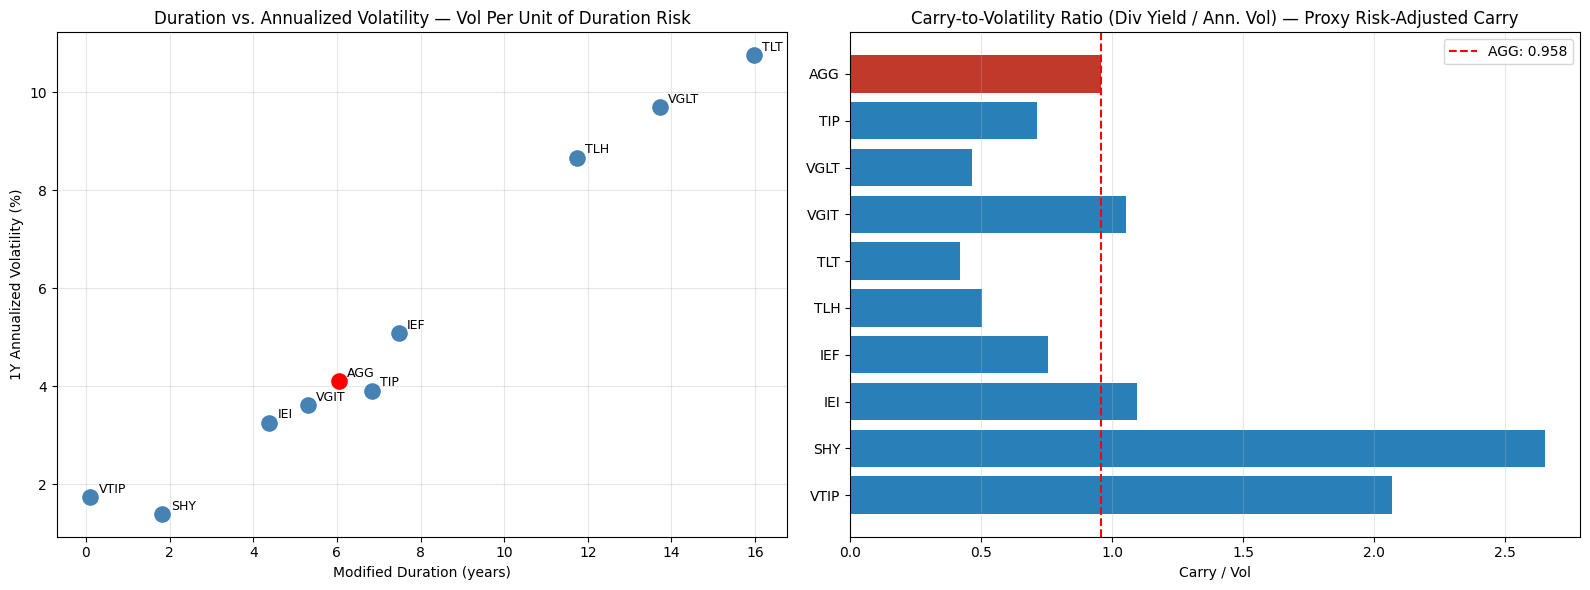


=== Risk-Adjusted Carry (Div Yield / Ann. Vol) ===
  SHY  : 2.6522   (yield 3.72% / vol 1.40%)
  VTIP : 2.0682   (yield 3.61% / vol 1.75%)
  IEI  : 1.0948   (yield 3.57% / vol 3.26%)
  VGIT : 1.0537   (yield 3.82% / vol 3.63%)
  AGG  : 0.9583   (yield 3.94% / vol 4.11%)
  IEF  : 0.7544   (yield 3.84% / vol 5.09%)
  TIP  : 0.7123   (yield 2.79% / vol 3.92%)
  TLH  : 0.5030   (yield 4.36% / vol 8.67%)
  VGLT : 0.4668   (yield 4.53% / vol 9.70%)
  TLT  : 0.4204   (yield 4.52% / vol 10.75%)


In [32]:
# Duration vs volatility — how much vol are we buying per year of duration?
vols = {tk: raw[tk]["Close"].pct_change().rolling(252).std().iloc[-1] * np.sqrt(252) * 100 for tk in TICKERS}
durs = {tk: ETF_META[tk]["mod_duration"] for tk in TICKERS}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Vol vs duration
for tk in TICKERS:
    color = "red" if tk == BENCH else "steelblue"
    axes[0].scatter(durs[tk], vols[tk], s=120, color=color, zorder=3)
    axes[0].annotate(tk, (durs[tk], vols[tk]), textcoords="offset points", xytext=(6, 3), fontsize=9)
axes[0].set_title("Duration vs. Annualized Volatility — Vol Per Unit of Duration Risk")
axes[0].set_xlabel("Modified Duration (years)")
axes[0].set_ylabel("1Y Annualized Volatility (%)")
axes[0].grid(True, alpha=0.3)

# Sharpe-style ratio: dividend yield / volatility
sharpe_proxy = {tk: df_compare.loc[tk, "Div Yield %"] / vols[tk] for tk in TICKERS}
axes[1].barh(list(sharpe_proxy.keys()), list(sharpe_proxy.values()),
             color=["#c0392b" if tk == BENCH else "#2980b9" for tk in sharpe_proxy])
axes[1].set_title("Carry-to-Volatility Ratio (Div Yield / Ann. Vol) — Proxy Risk-Adjusted Carry")
axes[1].set_xlabel("Carry / Vol")
axes[1].axvline(sharpe_proxy[BENCH], color="red", linestyle="--", linewidth=1.5, label=f"AGG: {sharpe_proxy[BENCH]:.3f}")
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis="x")

plt.tight_layout()
plt.show()

print("\n=== Risk-Adjusted Carry (Div Yield / Ann. Vol) ===")
for tk, val in sorted(sharpe_proxy.items(), key=lambda x: -x[1]):
    print(f"  {tk:5s}: {val:.4f}   (yield {df_compare.loc[tk,'Div Yield %']:.2f}% / vol {vols[tk]:.2f}%)")

## Excel Export

Writes all key tables to `output/etf_analysis.xlsx` via `NotebookWorkbook`.  
Re-run this cell any time to refresh the workbook with latest data.

In [36]:
from tools.excel import NotebookWorkbook

OUT_PATH = data.PROJECT_ROOT / "models" / "treasuries_spring26" / "output" / "etf_analysis.xlsx"
wb = NotebookWorkbook(OUT_PATH)

# ── Sheet 1: ETF Comparison Table ────────────────────────────────────────────
wb.write("ETF Comparison", df_compare.reset_index())

# ── Sheet 2: Carry Analysis ───────────────────────────────────────────────────
df_carry = pd.DataFrame([
    {
        "Ticker":         tk,
        "Div_Yield_pct":  df_compare.loc[tk, "Div Yield %"],
        "Mod_Duration":   ETF_META[tk]["mod_duration"],
        "Convexity":      ETF_META[tk]["convexity"],
        "Expense_Ratio":  ETF_META[tk]["expense_ratio"],
        "Net_Carry_pct":  df_compare.loc[tk, "Div Yield %"] - ETF_META[tk]["expense_ratio"],
        "Carry_per_Dur":  carry_dur[tk],
        "Vol_1Y_pct":     vols[tk],
        "Carry_per_Vol":  sharpe_proxy[tk],
    }
    for tk in TICKERS
])
wb.write("Carry Analysis", df_carry)

# ── Sheet 3: Yield Curve Snapshot ─────────────────────────────────────────────
df_curve = pd.DataFrame({
    "Maturity":    labels,
    "Maturity_Yr": maturities,
    "Yield_Now":   curve_now,
    "Yield_1Y_Ago": curve_1y,
})
wb.write("Yield Curve", df_curve)

# ── Sheet 4: Yield Curve Percentile Bands ────────────────────────────────────
df_pct_bands = pd.DataFrame({
    "Maturity":     labels,
    "Maturity_Yr":  maturities,
    "Yield_Now":    curve_now,
    "Yield_1Y_Ago": curve_1y,
    "p10":          p10.tolist(),
    "p25":          p25.tolist(),
    "p75":          p75.tolist(),
    "p90":          p90.tolist(),
})
wb.write("Curve Percentiles", df_pct_bands)

# ── Sheet 5: Duration Risk (rate shock price impacts) ────────────────────────────
shock_rows = []
for tk in TICKERS:
    d = ETF_META[tk]["mod_duration"]
    c = ETF_META[tk]["convexity"]
    row = {"Ticker": tk, "Mod_Duration": d, "Convexity": c}
    for s in [25, 50, 100, 200]:
        row[f"+{s}bp_pct"] = round((-d*(s/100) + 0.5*c*(s/100)**2)*100, 3)
    shock_rows.append(row)
wb.write("Duration Risk", pd.DataFrame(shock_rows))

# ── Sheet 6: AGG Benchmark Summary ─────────────────────────────────────────────
df_agg_summary = pd.DataFrame([
    ("Latest Close ($)",       round(agg["Close"].iloc[-1], 2)),
    ("YTD Return (%)",         round(ytd_ret, 2)),
    ("1-Year Return (%)",      round(ret_1y, 2)),
    ("3-Year Return (%)",      round(ret_3y, 2) if not np.isnan(ret_3y) else None),
    ("Mod Duration (yrs)",     agg_dur),
    ("DV01 (per $100 NAV)",    round(dv01, 4)),
    ("Ann. Volatility 1Y (%)", round(vol_ann, 2)),
    ("Expense Ratio (%)",      ETF_META["AGG"]["expense_ratio"]),
], columns=["Metric", "Value"])
wb.write("AGG Summary", df_agg_summary)

# ── Sheet 7: AGG NAV vs 10Y Yield + Rolling Vol ────────────────────────────
t10 = df_master["DGS10"].dropna()
roll_vol_63 = agg["Close"].pct_change().rolling(63).std() * np.sqrt(252) * 100
t10_aligned = t10.reindex(agg.index)
df_agg_nav = pd.DataFrame({
    "Date":                agg.index,
    "AGG_Close":           agg["Close"].values,
    "DGS10_Yield":         t10_aligned.values,
    "AGG_Rolling_Vol_63d": roll_vol_63.values,
})
wb.write("AGG NAV vs 10Y", df_agg_nav)

# ── Sheet 8: Inflation Decomposition ───────────────────────────────────────────
fwd_aligned = df_master["T5YIFR"].dropna().reindex(common_idx)
df_inflation = pd.DataFrame({
    "Date":               common_idx,
    "Nominal_10Y":        t10_nom[common_idx].values,
    "Breakeven_10Y":      t10_be[common_idx].values,
    "Real_10Y":           real_10y.values,
    "Fwd_5Y5Y_Inflation": fwd_aligned.values,
})
wb.write("Inflation Decomp", df_inflation)

# ── Sheet 9: Curve Slopes ─────────────────────────────────────────────────────
common_slopes = slope_2s10s.index.intersection(slope_5s30s.index).intersection(butterfly.index)
df_slopes = pd.DataFrame({
    "Date":              common_slopes,
    "Slope_2s10s":       slope_2s10s.reindex(common_slopes).values,
    "Slope_5s30s":       slope_5s30s.reindex(common_slopes).values,
    "Butterfly_2s5s10s": butterfly.reindex(common_slopes).values,
})
wb.write("Curve Slopes", df_slopes)

# ── Sheet 10: Credit Spreads ──────────────────────────────────────────────────
hy  = df_master["BAMLH0A0HYM2"].dropna()
ig  = df_master["BAMLC0A0CM"].dropna()
bbb = df_master["BAMLC0A4CBBB"].dropna()
common_sprd = hy.index.intersection(ig.index).intersection(bbb.index)
df_spreads = pd.DataFrame({
    "Date":        common_sprd,
    "HY_OAS_bps":  hy.reindex(common_sprd).values,
    "IG_OAS_bps":  ig.reindex(common_sprd).values,
    "BBB_OAS_bps": bbb.reindex(common_sprd).values,
})
wb.write("Credit Spreads", df_spreads)

# ── Sheet 11: ETF Drawdowns ───────────────────────────────────────────────────────
dd_tickers = ["VTIP", "SHY", "IEF", "TLT", "AGG"]
dd_dict = {}
dd_idx = None
for tk in dd_tickers:
    p = raw[tk]["Close"]
    dd = (p / p.cummax() - 1) * 100
    dd_dict[tk] = dd
    if dd_idx is None:
        dd_idx = dd.index
df_dd = pd.DataFrame(dd_dict, index=dd_idx).reset_index().rename(columns={"index": "Date"})
wb.write("ETF Drawdowns", df_dd)

# ── Sheet 12: ETF Rebased Returns ────────────────────────────────────────────────
rebase_tickers = ["VTIP", "SHY", "IEI", "IEF", "TLT", "AGG"]
rb_dict = {}
rb_idx = None
for tk in rebase_tickers:
    p = raw[tk]["Close"]
    rb = (p / p.iloc[0]) * 100
    rb_dict[tk] = rb
    if rb_idx is None:
        rb_idx = rb.index
df_rebased = pd.DataFrame(rb_dict, index=rb_idx).reset_index().rename(columns={"index": "Date"})
wb.write("ETF Rebased Returns", df_rebased)

# ── Sheet 13: Prices 5Y ───────────────────────────────────────────────────────────────
wb.write("Prices 5Y", prices.reset_index().rename(columns={"index": "Date"}))

# ── Sheet 14: Yield vs AGG ───────────────────────────────────────────────────────────
agg_yield = df_compare.loc["AGG", "Div Yield %"]
df_yield_vs_agg = pd.DataFrame([
    {
        "Ticker":          tk,
        "Div_Yield_pct":   df_compare.loc[tk, "Div Yield %"],
        "Diff_vs_AGG_pct": round(df_compare.loc[tk, "Div Yield %"] - agg_yield, 2),
        "Mod_Duration":    ETF_META[tk]["mod_duration"],
        "Dur_vs_AGG":      df_compare.loc[tk, "Dur vs AGG"],
    }
    for tk in TICKERS
])
wb.write("Yield vs AGG", df_yield_vs_agg)

vol_dur = pd.DataFrame([
    {
        "Ticker": tk,
        "Volatility": vols[tk],
        "Duration": durs[tk]
    }
    for tk in TICKERS
])
wb.write("Vol vs Duration", vol_dur)

path = wb.save()
print(f"Saved → {path}")
import openpyxl
print(f"Sheets: {list(openpyxl.load_workbook(path).sheetnames)}")


Saved → C:\Users\btm74.000\Projects\qf_toolset\models\treasuries_spring26\output\etf_analysis.xlsx
Sheets: ['ETF Comparison', 'Carry Analysis', 'Yield Curve', 'Curve Percentiles', 'Duration Risk', 'AGG Summary', 'AGG NAV vs 10Y', 'Inflation Decomp', 'Curve Slopes', 'Credit Spreads', 'ETF Drawdowns', 'ETF Rebased Returns', 'Prices 5Y', 'Yield vs AGG', 'Vol vs Duration']
